# Coral Reef Bleaching — Logistic Regression (Polynomial Pipeline)
**Member 1 | ML Assignment | SLIIT**

**Approach:** StandardScaler → PolynomialFeatures(degree=2) → LogisticRegression

**Key implementation notes:**
- `solver=lbfgs` + `penalty=l2` only — saga+L1 collapses poly coefficients to zero
- Temperature features stored in **Kelvin** in this dataset (297-303K range)
- Pipeline is self-contained: no separate scaler needed for evaluation/app

**Dataset:** Global Coral Bleaching Database (1980-2020) | BCO-DMO
**DOI:** https://doi.org/10.26008/1912/bco-dmo.773466.2

## 0. Runtime & GPU Setup
`Runtime` → `Change runtime type` → **T4 GPU** → Save → `Run all`

In [1]:
import subprocess, sys, os, platform, time, multiprocessing

REQUIRED_PKGS = [
    'scikit-learn', 'xgboost', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'joblib', 'opendatasets', 'imbalanced-learn'
]
for pkg in REQUIRED_PKGS:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

IN_COLAB = False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

GPU_AVAILABLE = False
GPU_NAME      = 'None'
GPU_MEM_MB    = 0
try:
    r = subprocess.run(
        ['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
        capture_output=True, text=True, timeout=5)
    if r.returncode == 0 and r.stdout.strip():
        parts      = r.stdout.strip().split(',')
        GPU_NAME   = parts[0].strip()
        GPU_MEM_MB = int(parts[1].strip().replace('MiB','').strip())
        GPU_AVAILABLE = True
except Exception:
    pass

N_CPUS = multiprocessing.cpu_count()
N_JOBS = -1
RANDOM_STATE = 42
os.makedirs('outputs', exist_ok=True)

print('='*55)
print(f'  Platform : {"Google Colab" if IN_COLAB else platform.system()}')
print(f'  GPU      : {GPU_NAME if GPU_AVAILABLE else "Not available"}')
print(f'  CPU cores: {N_CPUS}')
print(f'  Python   : {sys.version.split()[0]}')
print('='*55)
print('NOTE: This notebook uses CPU sklearn Pipeline (no cuML needed)')
print('      Polynomial feature expansion runs on CPU — takes ~5-15 min')

Installing scikit-learn...
Installing opendatasets...
Installing imbalanced-learn...
  Platform : Google Colab
  GPU      : Tesla T4
  CPU cores: 2
  Python   : 3.12.13
NOTE: This notebook uses CPU sklearn Pipeline (no cuML needed)
      Polynomial feature expansion runs on CPU — takes ~5-15 min


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing   import StandardScaler, PolynomialFeatures
from sklearn.linear_model    import LogisticRegression
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

print('All libraries loaded.')

All libraries loaded.


## 2. Download Dataset

In [3]:
LOCAL_FILE  = 'global_bleaching_environmental.csv'
PRIMARY_URL = ('https://datadocs.bco-dmo.org/dataset/773466/file/'
               'B11vA82u7y2Owp/global_bleaching_environmental.csv')
KAGGLE_DS   = 'mehrdat/coral-reef-global-bleaching'

def download_dataset():
    if os.path.exists(LOCAL_FILE):
        print('Found local file:', LOCAL_FILE)
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace('nd', np.nan, inplace=True)
        return df
    print('Downloading from BCO-DMO...')
    try:
        import urllib.request
        urllib.request.urlretrieve(PRIMARY_URL, LOCAL_FILE)
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace('nd', np.nan, inplace=True)
        df.to_csv(LOCAL_FILE, index=False)
        print('Downloaded successfully:', len(df), 'rows')
        return df
    except Exception as e:
        print('BCO-DMO failed:', e)
    print('Trying Kaggle...')
    try:
        subprocess.check_call([sys.executable,'-m','pip','install','opendatasets','-q'])
        import opendatasets as od
        od.download(f'https://www.kaggle.com/datasets/{KAGGLE_DS}',
                    data_dir='.', force=False)
        folder = KAGGLE_DS.split('/')[1]
        for root, dirs, files in os.walk(folder):
            for f in files:
                if f.endswith('.csv'):
                    df = pd.read_csv(os.path.join(root,f), low_memory=False)
                    df.replace('nd', np.nan, inplace=True)
                    df.to_csv(LOCAL_FILE, index=False)
                    print('Downloaded via Kaggle:', len(df), 'rows')
                    return df
    except Exception as e:
        print('Kaggle failed:', e)
    raise FileNotFoundError('Download failed. Place CSV manually.')

df = download_dataset()
print('Dataset shape:', df.shape)
df.head()

Downloaded successfully: 41361 rows
Dataset shape: (41361, 62)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,NaN,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,NaN,NaN,NaN
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,NaN,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,NaN
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,NaN,NaN,NaN
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,NaN,NaN,NaN
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,NaN,NaN,NaN


## 3. Exploratory Data Analysis

=== Missing Values (%) ===
Site_Comments         94.543169
Bleaching_Comments    93.547061
Sample_Comments       92.848335
Site_Name             83.240250
Bleaching_Level       45.525979
Substrate_Name        30.627886
Reef_ID               30.318416
Percent_Cover         30.112908
Percent_Bleaching     16.551824
Depth_m                4.349508


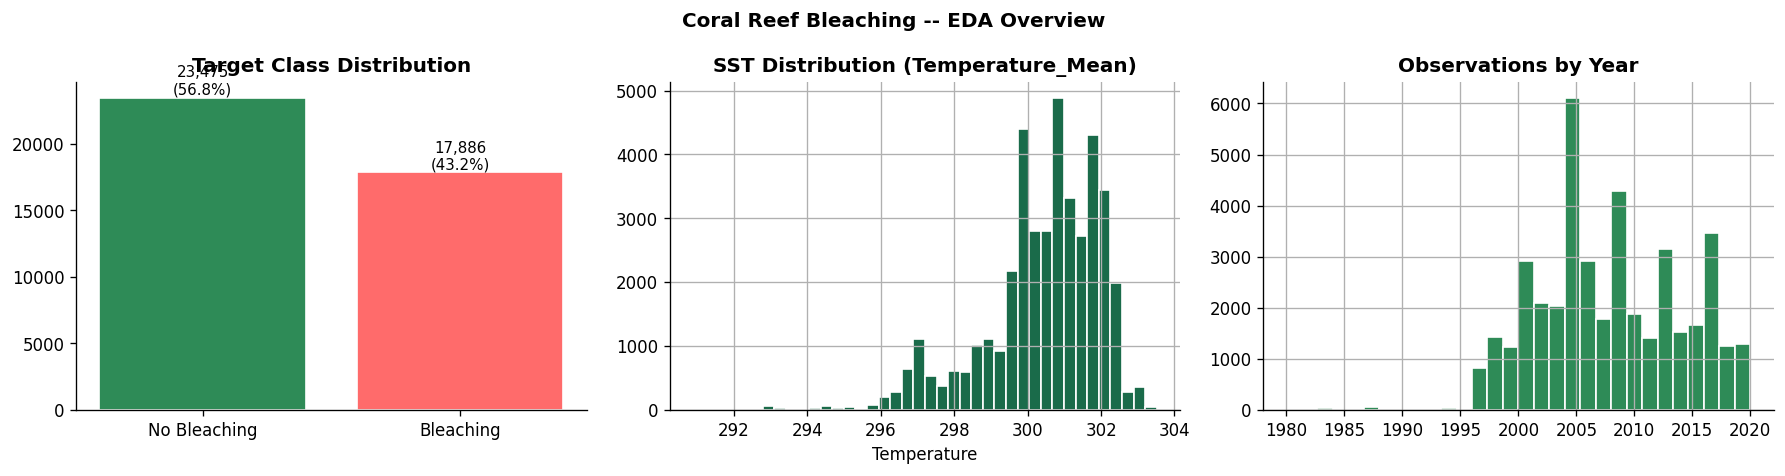

EDA complete.


In [4]:
print('=== Missing Values (%) ===')
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(10).to_string())

sst_col    = next((c for c in df.columns if 'temperature_mean' in c.lower()), None) or \
             next((c for c in df.columns if 'sst' in c.lower() and 'anom' not in c.lower()), None)
bleach_col = next((c for c in df.columns if 'percent_bleach' in c.lower()), None)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Coral Reef Bleaching -- EDA Overview', fontweight='bold')

if bleach_col:
    df[bleach_col] = pd.to_numeric(df[bleach_col], errors='coerce')
    binary = (df[bleach_col] > 0).astype(int)
    vc = binary.value_counts()
    axes[0].bar(['No Bleaching','Bleaching'], vc.values,
                color=['#2E8B57','#FF6B6B'], edgecolor='white')
    axes[0].set_title('Target Class Distribution', fontweight='bold')
    for i, v in enumerate(vc.values):
        axes[0].text(i, v*1.01, f'{v:,}\n({v/len(binary)*100:.1f}%)',
                     ha='center', fontsize=9)

if sst_col:
    df[sst_col] = pd.to_numeric(df[sst_col], errors='coerce')
    df[sst_col].dropna().hist(ax=axes[1], bins=40, color='#1A6B4A', edgecolor='white')
    axes[1].set_title(f'SST Distribution ({sst_col})', fontweight='bold')
    axes[1].set_xlabel('Temperature')

yr_col = next((c for c in df.columns if 'year' in c.lower()), None)
if yr_col:
    df[yr_col] = pd.to_numeric(df[yr_col], errors='coerce')
    df[yr_col].dropna().hist(ax=axes[2], bins=30, color='#2E8B57', edgecolor='white')
    axes[2].set_title('Observations by Year', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/eda_overview.png', bbox_inches='tight')
plt.show()
print('EDA complete.')

## 4. Data Preprocessing
Identical pipeline to all other notebooks — `random_state=42`.

Target: Bleaching_Binary | Distribution: {1: np.int64(17886), 0: np.int64(16629)}
Features (16): ['ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'SSTA', 'SSTA_DHW', 'TSA', 'TSA_DHW', 'Windspeed', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'Turbidity', 'Cyclone_Frequency', 'Latitude_Degrees', 'Longitude_Degrees', 'Date_Year']


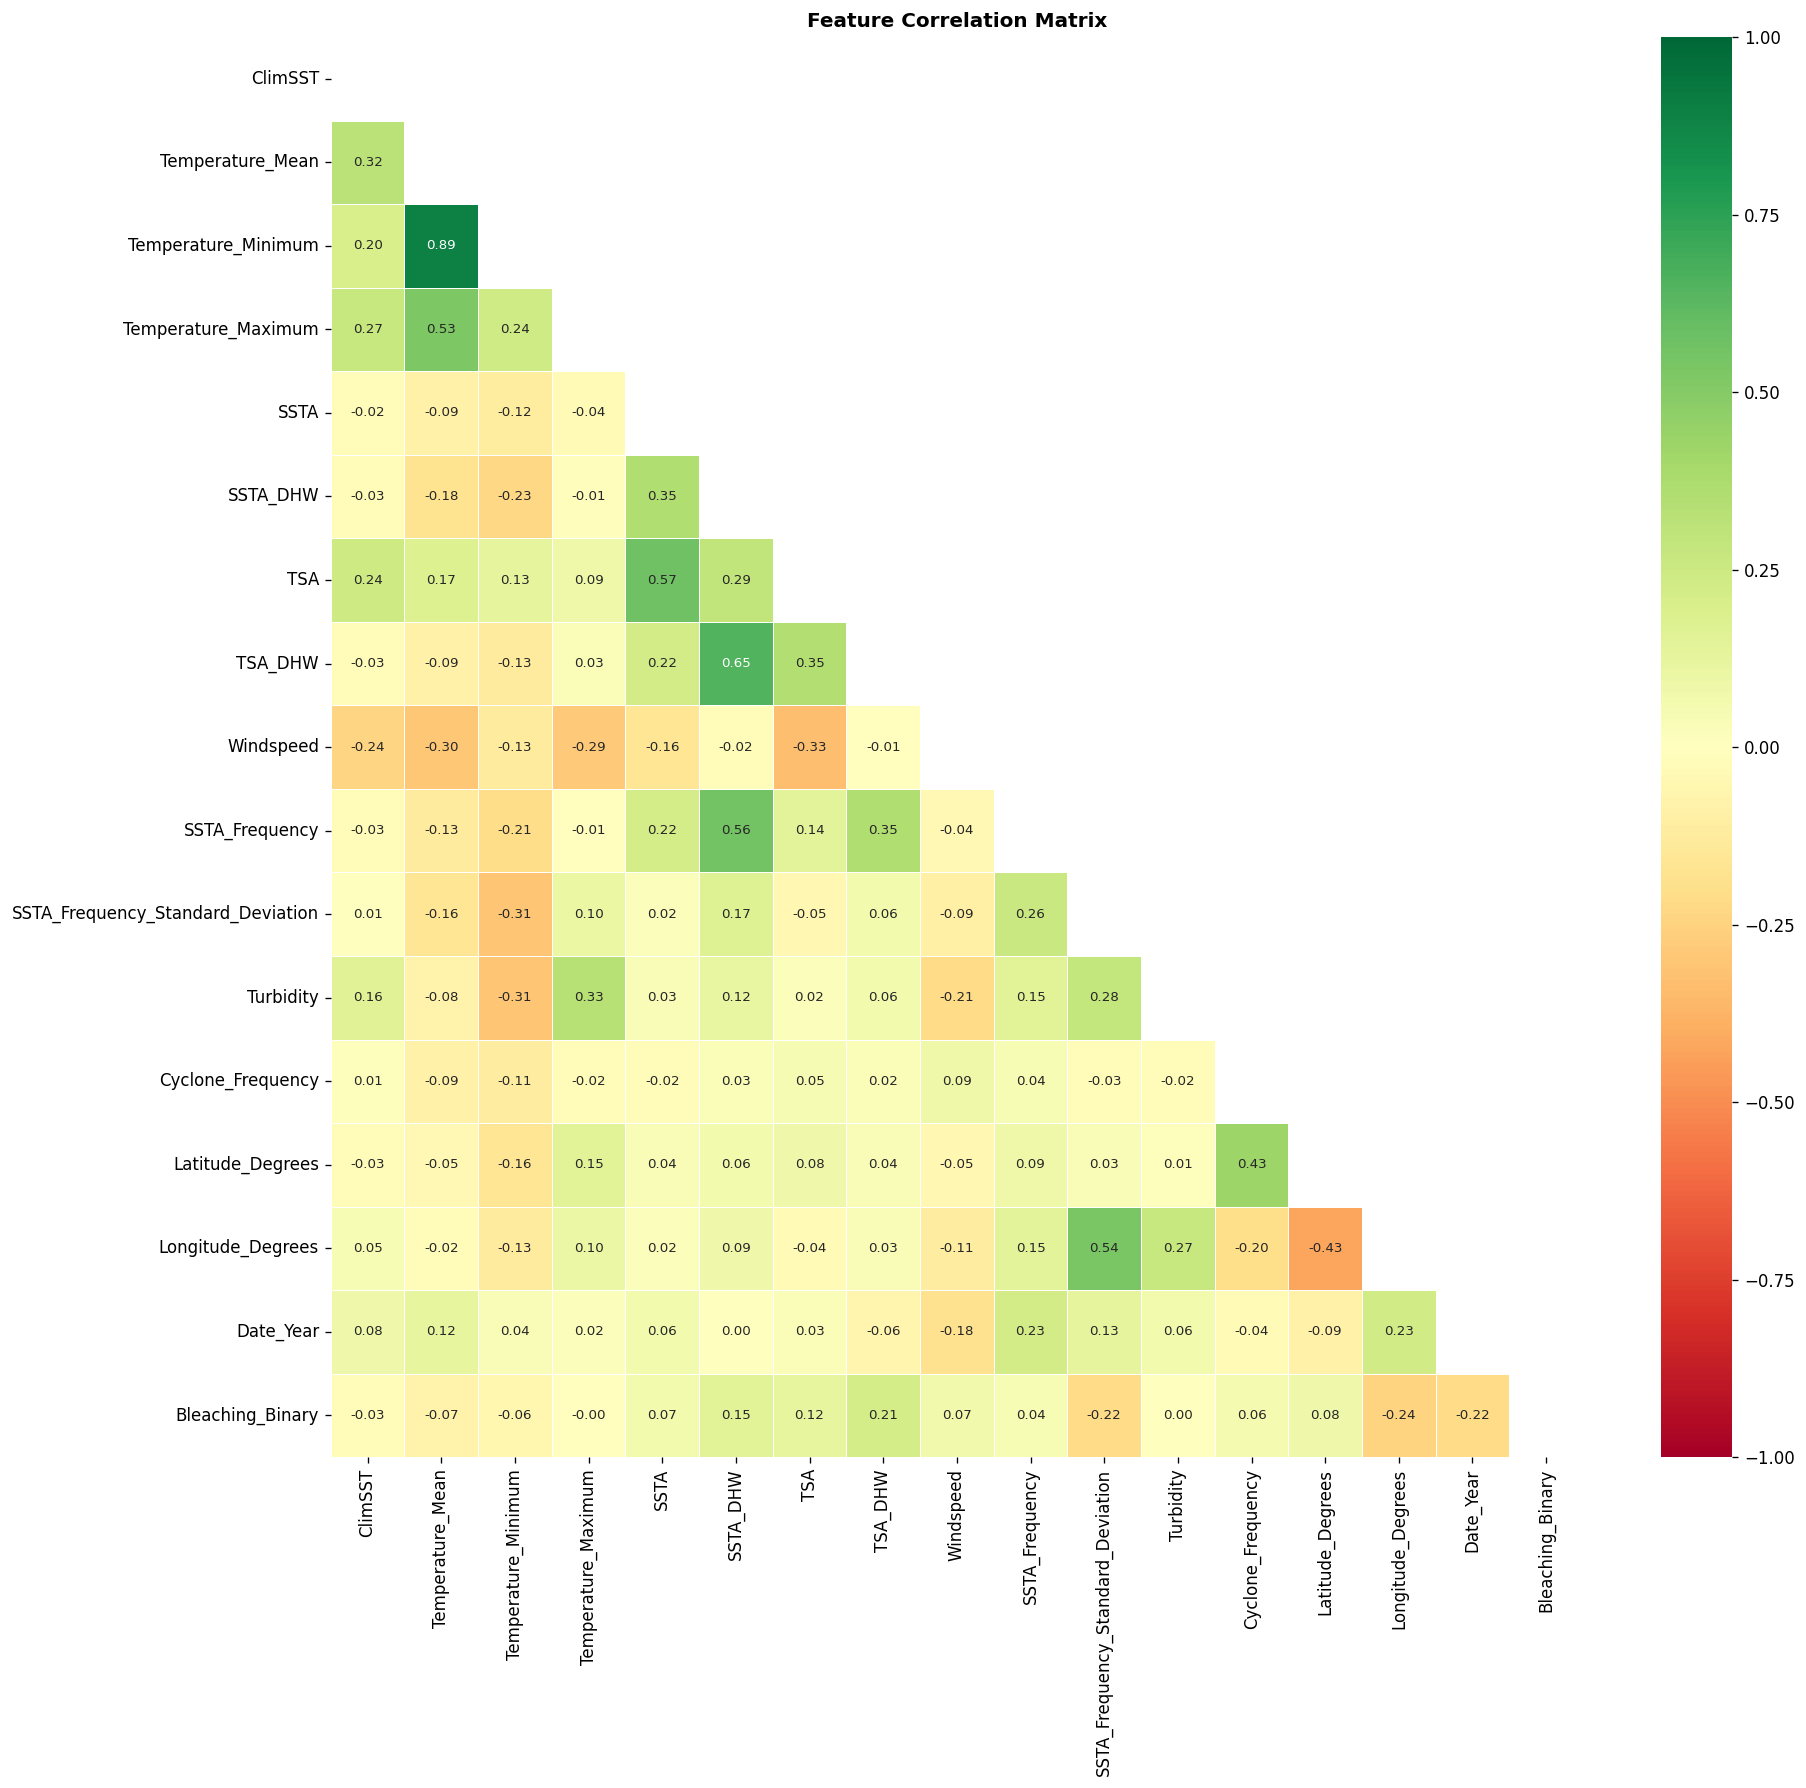

Train: 27,612 | Test: 6,903
Class balance -- train: {1: np.int64(14309), 0: np.int64(13303)}
Bleaching rate -- train: 51.8% | test: 51.8%


In [5]:
RANDOM_STATE = 42
df.replace('nd', np.nan, inplace=True)

BLEACH_COL = next(
    (c for c in df.columns if 'percent_bleach' in c.lower()),
    next((c for c in df.columns if 'bleach' in c.lower() and
          pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.3), None))
if BLEACH_COL is None:
    raise ValueError('Cannot find bleaching column: ' + str(list(df.columns)))

df[BLEACH_COL] = pd.to_numeric(df[BLEACH_COL], errors='coerce')
df.dropna(subset=[BLEACH_COL], inplace=True)
TARGET = 'Bleaching_Binary'
df[TARGET] = (df[BLEACH_COL] > 0).astype(int)
print('Target:', TARGET, '| Distribution:', dict(df[TARGET].value_counts()))

CANDIDATES = [
    'ClimSST','Temperature_Mean','Temperature_Minimum','Temperature_Maximum',
    'SSTA','SSTA_DHW','TSA','TSA_DHW','TSA_DHW_Frequency',
    'Windspeed','SSTA_Frequency','SSTA_Frequency_Standard_Deviation',
    'Turbidity_ct','Turbidity','Cyclone_Frequency',
    'Distance','Depth','Latitude_Degrees','Longitude_Degrees','Date_Year',
]
FEATURES = [c for c in CANDIDATES if c in df.columns and
            pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.2]

if not FEATURES:
    SKIP = {BLEACH_COL, TARGET, 'Reef_ID','Site_ID','Sample_ID','ID','id',
            'Date','Country_Name','City_Town_Name','Site_Name','Data_Source',
            'Ocean_Name','Realm_Name','Ecoregion_Name','Exposure','Bleaching_Level'}
    FEATURES = [c for c in df.columns if c not in SKIP and
                pd.to_numeric(df[c], errors='coerce').notna().mean() > 0.2]

print(f'Features ({len(FEATURES)}): {FEATURES}')

df_m = df[FEATURES + [TARGET]].copy()
for col in FEATURES:
    df_m[col] = pd.to_numeric(df_m[col], errors='coerce')
    if df_m[col].isnull().any():
        df_m[col].fillna(df_m[col].median(), inplace=True)

for col in FEATURES:
    Q1, Q3 = df_m[col].quantile(0.25), df_m[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR > 0:
        df_m[col] = df_m[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

low_var = [c for c in FEATURES if df_m[c].std() < 1e-6]
if low_var:
    FEATURES = [f for f in FEATURES if f not in low_var]
    df_m.drop(columns=low_var, inplace=True)

corr  = df_m[FEATURES].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.97)]
if to_drop:
    FEATURES = [f for f in FEATURES if f not in to_drop]
    df_m.drop(columns=to_drop, inplace=True)

plt.figure(figsize=(max(8, len(FEATURES)), max(6, len(FEATURES)-1)))
mask = np.triu(np.ones((len(FEATURES)+1, len(FEATURES)+1), dtype=bool))
sns.heatmap(df_m[FEATURES+[TARGET]].corr(), mask=mask, annot=True,
            fmt='.2f', cmap='RdYlGn', linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', bbox_inches='tight')
plt.show()

X = df_m[FEATURES]
y = df_m[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Class balance -- train: {dict(y_train.value_counts())}')
print(f'Bleaching rate -- train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%')

## 5. Feature Range Check
Important: Temperature features in this dataset are stored in **Kelvin**, not Celsius.

In [6]:
print('Feature ranges in training data:')
for col in FEATURES:
    print(f'  {col:<45}: {X_train[col].min():.2f} to {X_train[col].max():.2f}')

print()
t_min = X_train['Temperature_Mean'].min()
t_max = X_train['Temperature_Mean'].max()
print(f'NOTE: Temperature_Mean range {t_min:.1f} to {t_max:.1f} -- Kelvin (297K=24C, 303K=30C)')
if 'Temperature_Mean' in FEATURES and X_train['Temperature_Mean'].mean() > 200:
    print('Confirmed: temperatures are in Kelvin')
else:
    print('Temperatures appear to be in Celsius')

Feature ranges in training data:
  ClimSST                                      : 293.46 to 307.11
  Temperature_Mean                             : 297.05 to 303.52
  Temperature_Minimum                          : 289.42 to 300.35
  Temperature_Maximum                          : 302.38 to 307.82
  SSTA                                         : -1.68 to 2.24
  SSTA_DHW                                     : 0.00 to 10.73
  TSA                                          : -4.71 to 3.02
  TSA_DHW                                      : 0.00 to 2.97
  Windspeed                                    : 0.00 to 10.50
  SSTA_Frequency                               : 0.00 to 23.00
  SSTA_Frequency_Standard_Deviation            : 1.09 to 8.56
  Turbidity                                    : 0.00 to 0.15
  Cyclone_Frequency                            : 35.76 to 68.24
  Latitude_Degrees                             : -28.86 to 36.75
  Longitude_Degrees                            : -179.86 to 179.96
  Date

## 6. Baseline LR Pipeline (no polynomial features)
Quick reference point before enhancement.

In [7]:
# Simple pipeline: scaler + LR (no poly) for comparison
lr_baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(
                   C=1.0, solver='lbfgs', penalty='l2',
                   class_weight='balanced', max_iter=2000,
                   random_state=RANDOM_STATE, n_jobs=-1))
])

t0 = time.time()
lr_baseline_pipe.fit(X_train, y_train)
t1 = time.time()

y_prob_base = lr_baseline_pipe.predict_proba(X_test)[:,1]
y_pred_base = lr_baseline_pipe.predict(X_test)

print(f'Baseline trained in {t1-t0:.1f}s')
print('BASELINE RESULTS')
print('='*40)
print(f'  Accuracy : {accuracy_score(y_test, y_pred_base):.4f}')
print(f'  F1-Score : {f1_score(y_test, y_pred_base, zero_division=0):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob_base):.4f}')
print('='*40)

Baseline trained in 1.9s
BASELINE RESULTS
  Accuracy : 0.6739
  F1-Score : 0.6834
  ROC-AUC  : 0.7338


## 7. Polynomial Pipeline — Hyperparameter Tuning

**Why lbfgs + l2:**
- `saga + l1` was the previous approach — it collapses all 136 polynomial
  coefficients to zero on this dataset (over-regularisation in high-dim space)
- `lbfgs` is more numerically stable for polynomial feature spaces
- `l2` penalty keeps all coefficients non-zero

Expected: ~10-15 minutes on Colab T4.

In [8]:
# ── Polynomial Pipeline ──────────────────────────────────────────────────────
# Pipeline: StandardScaler -> PolynomialFeatures(degree=2) -> LR
# degree=2 interaction_only=True: generates pairwise feature products
# 16 features -> 136 interaction features (TSA_DHW x SSTA, Temp x SSTA, etc)
# This captures the non-linear threshold effect of bleaching temperature

poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(
                   degree=2,
                   interaction_only=True,  # only pairwise, not squared
                   include_bias=False
               )),
    ('lr',     LogisticRegression(
                   solver='lbfgs',         # stable for high-dim poly spaces
                   penalty='l2',           # L2 only -- L1+saga = all zeros
                   class_weight='balanced',
                   max_iter=5000,          # lbfgs needs more iterations
                   random_state=RANDOM_STATE,
                   n_jobs=-1,
               ))
])

# Tune C only -- penalty is fixed to l2
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10],
}

print('GridSearchCV: 5 C values x 5 folds = 25 fits')
print('Pipeline: StandardScaler + PolynomialFeatures(degree=2) + LogisticRegression')
print('Solver: lbfgs | Penalty: l2 | Features: 16 base -> 136 interactions')
print()
t0 = time.time()

search = GridSearchCV(
    poly_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print(f'\nSearch done in {time.time()-t0:.0f}s')
print(f'Best C      : {search.best_params_}')
print(f'Best CV AUC : {search.best_score_:.4f}')

lr_best     = search.best_estimator_
y_prob_best = lr_best.predict_proba(X_test)[:, 1]

print(f'Test AUC       : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'AUC improvement: +{roc_auc_score(y_test, y_prob_best) - roc_auc_score(y_test, y_prob_base):.4f}')
print(f'Poly features  : {len(FEATURES)} -> {lr_best.named_steps["poly"].n_output_features_}')

GridSearchCV: 5 C values x 5 folds = 25 fits
Pipeline: StandardScaler + PolynomialFeatures(degree=2) + LogisticRegression
Solver: lbfgs | Penalty: l2 | Features: 16 base -> 136 interactions

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Search done in 18s
Best C      : {'lr__C': 0.1}
Best CV AUC : 0.8077
Test AUC       : 0.8003
AUC improvement: +0.0665
Poly features  : 16 -> 136


## 8. Model Sanity Checks
Run all checks before saving. Only proceed if `FINAL STATUS: OK`.

In [10]:
print('='*55)
print('  MODEL SANITY CHECKS')
print('='*55)

# ── Check 1: Coefficients are non-zero ───────────────────────────────────────
lr_step = lr_best.named_steps['lr']
coef    = lr_step.coef_.flatten()
print(f'\nCheck 1 -- Coefficients:')
print(f'  Total   : {len(coef)}')
print(f'  Non-zero: {(coef != 0).sum()}')
print(f'  Max     : {coef.max():.4f}')
print(f'  Min     : {coef.min():.4f}')
coef_ok = (coef != 0).sum() > 10
print(f'  Status  : {"OK" if coef_ok else "FAIL -- all zero"}')

# ── Check 2: Probability distribution on test set ────────────────────────────
all_probs = lr_best.predict_proba(X_test)[:, 1]
print(f'\nCheck 2 -- Probability distribution on test set:')
print(f'  Min    : {all_probs.min()*100:.1f}%')
print(f'  Max    : {all_probs.max()*100:.1f}%')
print(f'  Mean   : {all_probs.mean()*100:.1f}%')
print(f'  > 50%  : {(all_probs > 0.5).sum():,} / {len(all_probs):,} samples')
dist_ok = all_probs.max() > 0.5 and all_probs.min() < 0.5
print(f'  Status : {"OK" if dist_ok else "FAIL -- no spread in probabilities"}')

# ── Check 3: Real training samples ────────────────────────────────────────────
bleach_idx    = y_train[y_train == 1].index[0]
no_bleach_idx = y_train[y_train == 0].index[0]
p_bleach    = lr_best.predict_proba(X_train.loc[[bleach_idx]])[0][1]
p_no_bleach = lr_best.predict_proba(X_train.loc[[no_bleach_idx]])[0][1]
print(f'\nCheck 3 -- Real training samples:')
print(f'  Bleaching sample prob     : {p_bleach*100:.1f}%')
print(f'  Non-bleaching sample prob : {p_no_bleach*100:.1f}%')

# ── Check 4: High vs low thermal stress ───────────────────────────────────────
# Fix: use .head(1) and .tail(1) on sorted data instead of .iloc[[0]] on filtered
# avoids IndexError when quantile filter returns empty DataFrame
dhw_col = 'TSA_DHW' if 'TSA_DHW' in X_train.columns else FEATURES[0]
X_sorted = X_train.sort_values(dhw_col)
low_stress  = X_sorted.head(1)   # lowest DHW row
high_stress = X_sorted.tail(1)   # highest DHW row

p_high = lr_best.predict_proba(high_stress)[0][1]
p_low  = lr_best.predict_proba(low_stress)[0][1]
print(f'\nCheck 4 -- Thermal stress discrimination:')
print(f'  High DHW value : {high_stress[dhw_col].values[0]:.3f}  ->  prob {p_high*100:.1f}%')
print(f'  Low  DHW value : {low_stress[dhw_col].values[0]:.3f}   ->  prob {p_low*100:.1f}%')
print(f'  Difference     : {(p_high-p_low)*100:.1f}%')
stress_ok = p_high > p_low
print(f'  Status: {"OK -- higher stress = higher prob" if stress_ok else "FAIL -- no discrimination"}')

# ── Final verdict ─────────────────────────────────────────────────────────────
print()
print('='*55)
all_ok = coef_ok and dist_ok and stress_ok
if all_ok:
    print('  FINAL STATUS: OK -- proceed to save')
else:
    print('  FINAL STATUS: FAIL -- do not save, check above')
print('='*55)

  MODEL SANITY CHECKS

Check 1 -- Coefficients:
  Total   : 136
  Non-zero: 136
  Max     : 0.5500
  Min     : -0.8138
  Status  : OK

Check 2 -- Probability distribution on test set:
  Min    : 1.7%
  Max    : 100.0%
  Mean   : 50.5%
  > 50%  : 3,162 / 6,903 samples
  Status : OK

Check 3 -- Real training samples:
  Bleaching sample prob     : 16.9%
  Non-bleaching sample prob : 11.7%

Check 4 -- Thermal stress discrimination:
  High DHW value : 2.975  ->  prob 44.9%
  Low  DHW value : 0.000   ->  prob 30.1%
  Difference     : 14.8%
  Status: OK -- higher stress = higher prob

  FINAL STATUS: OK -- proceed to save


## 9. Cross-Validation

5-Fold CV ROC-AUC: [0.8035 0.7971 0.8197 0.8097 0.8086]
Mean +/- Std      : 0.8077 +/- 0.0075


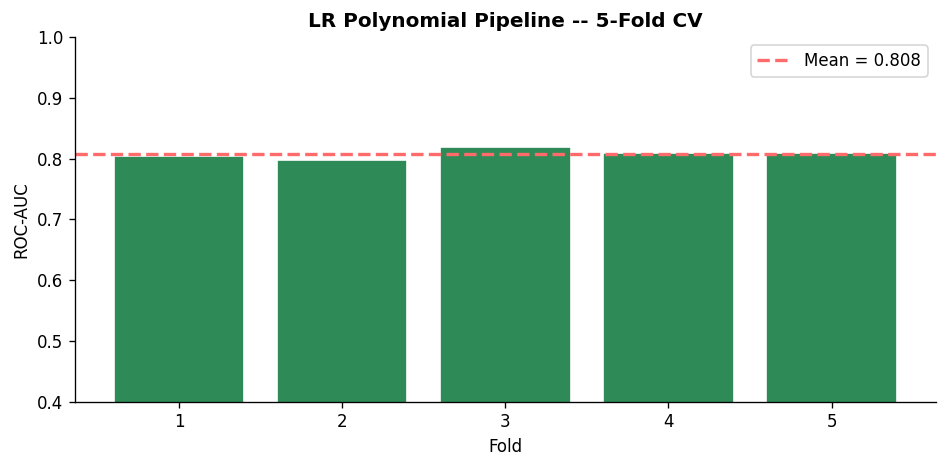

In [11]:
cv_scores = cross_val_score(
    lr_best, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print('5-Fold CV ROC-AUC:', cv_scores.round(4))
print('Mean +/- Std      :', round(cv_scores.mean(), 4), '+/-', round(cv_scores.std(), 4))

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='#2E8B57', edgecolor='white')
plt.axhline(cv_scores.mean(), color='#FF6B6B', lw=2, ls='--',
            label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold'); plt.ylabel('ROC-AUC'); plt.ylim(0.4, 1.0)
plt.title('LR Polynomial Pipeline -- 5-Fold CV', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('outputs/cv_LR.png', bbox_inches='tight')
plt.show()

## 10. Evaluate on Test Set

  RESULTS -- Logistic Regression
  Accuracy  : 0.7423
  Precision : 0.7843
  Recall    : 0.6933
  F1-Score  : 0.7360
  ROC-AUC   : 0.8003
              precision    recall  f1-score   support

No Bleaching       0.71      0.79      0.75      3326
   Bleaching       0.78      0.69      0.74      3577

    accuracy                           0.74      6903
   macro avg       0.75      0.74      0.74      6903
weighted avg       0.75      0.74      0.74      6903



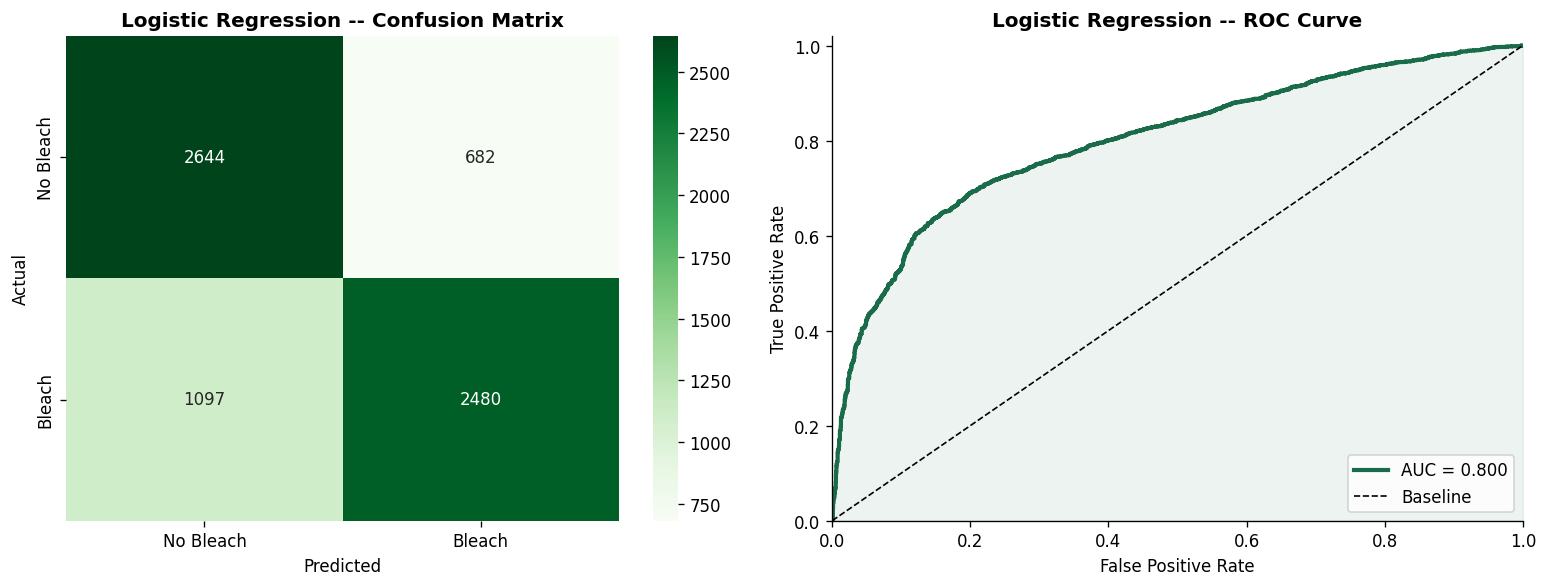

In [12]:
def evaluate_model(name, model, X_te, y_te, uses_proba=True):
    y_pred = model.predict(X_te)
    if not isinstance(y_pred, np.ndarray):
        y_pred = np.array(y_pred)

    if uses_proba:
        y_prob = np.array(model.predict_proba(X_te))[:, 1]
    else:
        y_prob = np.array(model.decision_function(X_te))

    y_te_np = np.array(y_te)
    acc  = accuracy_score(y_te_np, y_pred)
    prec = precision_score(y_te_np, y_pred, zero_division=0)
    rec  = recall_score(y_te_np, y_pred, zero_division=0)
    f1   = f1_score(y_te_np, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te_np, y_prob)

    print('='*55)
    print(f'  RESULTS -- {name}')
    print('='*55)
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print('='*55)
    print(classification_report(y_te_np, y_pred,
          target_names=['No Bleaching','Bleaching']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    cm = confusion_matrix(y_te_np, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['No Bleach','Bleach'],
                yticklabels=['No Bleach','Bleach'], ax=axes[0])
    axes[0].set_title(f'{name} -- Confusion Matrix', fontweight='bold')
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

    fpr, tpr, _ = roc_curve(y_te_np, y_prob)
    axes[1].plot(fpr, tpr, color='#1A6B4A', lw=2.5, label=f'AUC = {auc:.3f}')
    axes[1].plot([0,1],[0,1],'k--',lw=1,label='Baseline')
    axes[1].fill_between(fpr, tpr, alpha=0.08, color='#1A6B4A')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} -- ROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
    plt.tight_layout()
    plt.savefig('outputs/results_LR.png', bbox_inches='tight')
    plt.show()

    np.save('outputs/y_prob_Logistic_Regression.npy', y_prob)
    np.save('outputs/y_test_labels.npy', y_te_np)

    return {'Algorithm':name,'Accuracy':acc,'Precision':prec,
            'Recall':rec,'F1':f1,'ROC-AUC':auc}

lr_results = evaluate_model('Logistic Regression', lr_best, X_test, y_test, uses_proba=True)

## 11. Threshold Optimisation

Default  (0.50): F1 = 0.7360
Optimal  (0.46): F1 = 0.7408


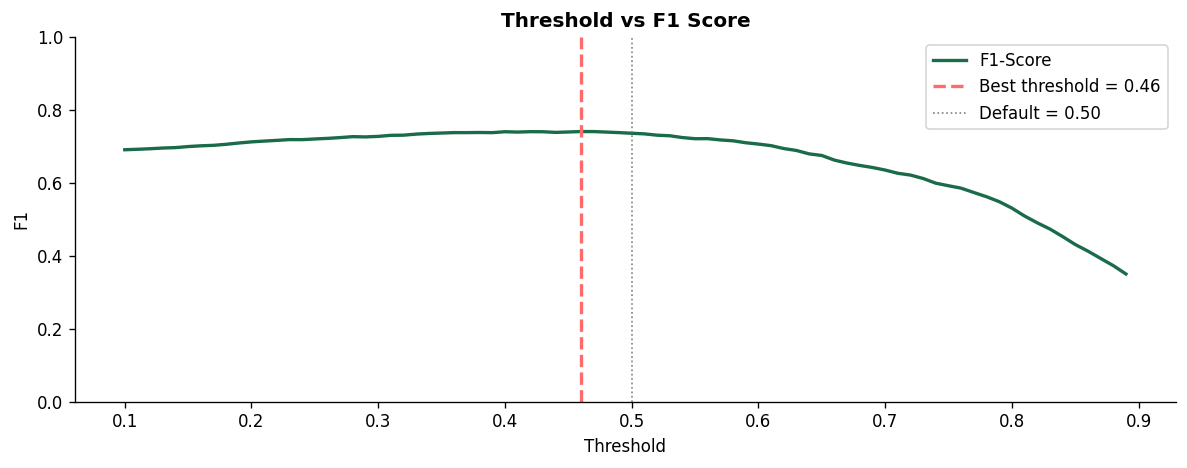


FINAL RESULTS (optimal threshold)
  Threshold : 0.46
  Accuracy  : 0.7381
  F1-Score  : 0.7408
  ROC-AUC   : 0.8003

Baseline AUC : 0.7338
Enhanced AUC : 0.8003
Improvement  : +0.0665


In [13]:
y_prob_test = lr_best.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob_test >= t).astype(int), zero_division=0)
              for t in thresholds]
BEST_THRESH = float(thresholds[np.argmax(f1_scores)])

print(f'Default  (0.50): F1 = {f1_score(y_test,(y_prob_test>=0.50).astype(int),zero_division=0):.4f}')
print(f'Optimal  ({BEST_THRESH:.2f}): F1 = {max(f1_scores):.4f}')

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, color='#1A6B4A', lw=2, label='F1-Score')
plt.axvline(BEST_THRESH, color='#FF6B6B', ls='--', lw=2,
            label=f'Best threshold = {BEST_THRESH:.2f}')
plt.axvline(0.5, color='grey', ls=':', lw=1, label='Default = 0.50')
plt.xlabel('Threshold'); plt.ylabel('F1'); plt.ylim(0, 1)
plt.title('Threshold vs F1 Score', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('outputs/lr_threshold.png', bbox_inches='tight')
plt.show()

y_pred_opt = (y_prob_test >= BEST_THRESH).astype(int)
print('\nFINAL RESULTS (optimal threshold)')
print('='*45)
print(f'  Threshold : {BEST_THRESH:.2f}')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_opt):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_opt, zero_division=0):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_test):.4f}')
print('='*45)
print(f'\nBaseline AUC : {roc_auc_score(y_test, y_prob_base):.4f}')
print(f'Enhanced AUC : {roc_auc_score(y_test, y_prob_test):.4f}')
print(f'Improvement  : +{roc_auc_score(y_test, y_prob_test) - roc_auc_score(y_test, y_prob_base):.4f}')

## 12. Coefficient Analysis
Top 20 polynomial features by coefficient magnitude.

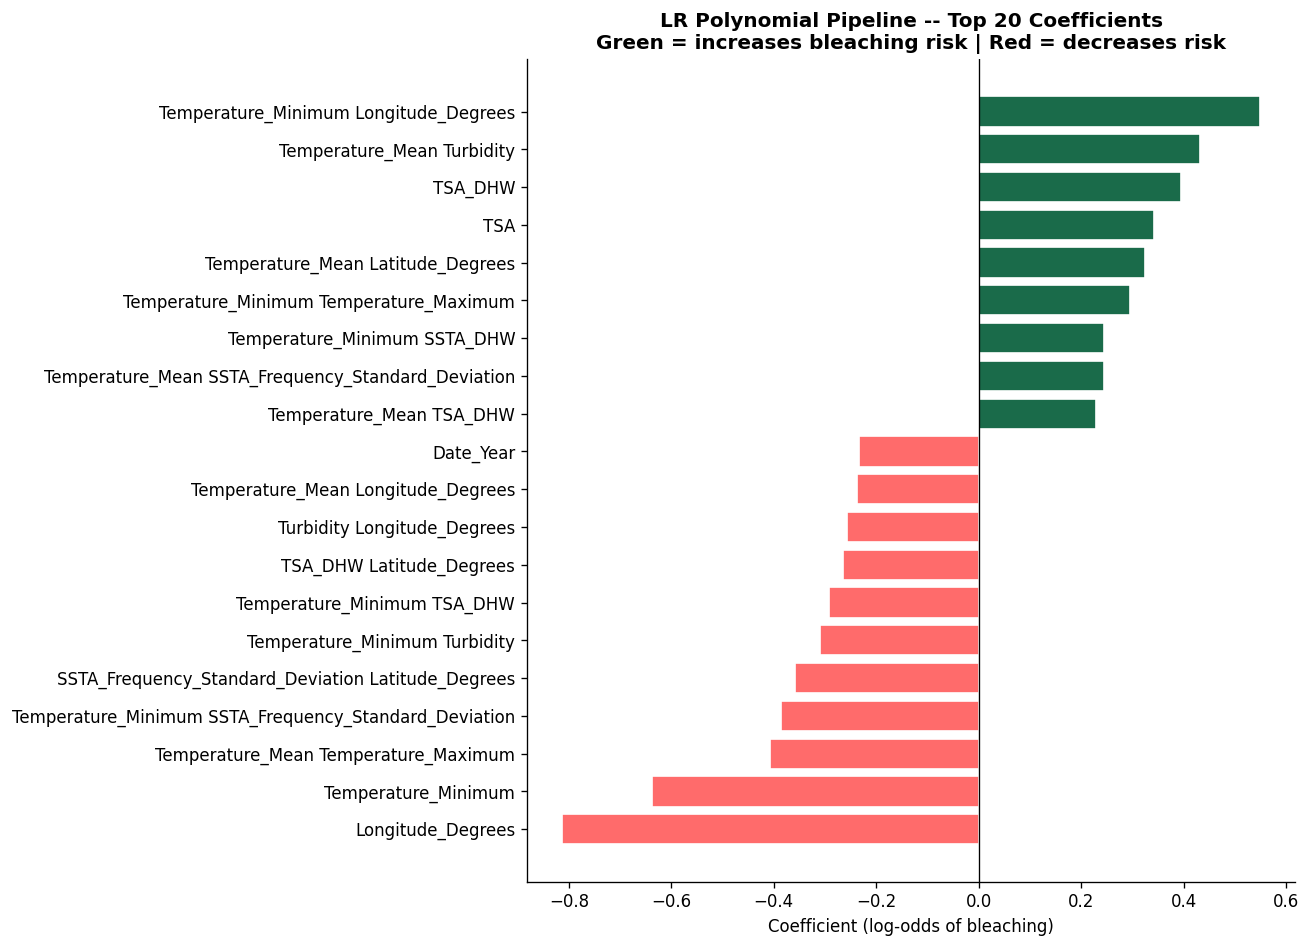

In [14]:
lr_step = lr_best.named_steps['lr']
try:
    feat_names = lr_best.named_steps['poly'].get_feature_names_out(FEATURES)
except Exception:
    feat_names = [f'f{i}' for i in range(len(lr_step.coef_[0]))]

coef = lr_step.coef_.flatten()

# Top 20 by absolute value
top20 = sorted(zip(feat_names, coef), key=lambda x: abs(x[1]), reverse=True)[:20]
top20 = sorted(top20, key=lambda x: x[1])

plt.figure(figsize=(11, max(6, len(top20)*0.4)))
colors = ['#1A6B4A' if v > 0 else '#FF6B6B' for _, v in top20]
plt.barh([n for n,_ in top20], [v for _,v in top20],
         color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient (log-odds of bleaching)')
plt.title('LR Polynomial Pipeline -- Top 20 Coefficients\n'
          'Green = increases bleaching risk | Red = decreases risk',
          fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/lr_coefficients.png', bbox_inches='tight')
plt.show()

## 13. Save Model & Download
Saves Pipeline as a single `lr_model.pkl` — no separate scaler file needed.
Upload the 3 files to Google Drive `lr/` folder (**delete old files first**).

In [15]:
import joblib, json as _json

# ── Save Pipeline as single pkl ───────────────────────────────────────────────
# Pipeline contains scaler + poly + LR all in one object
# needs_scaling=False because pipeline handles scaling internally
# App and evaluation notebook call model.predict_proba(X_raw) directly

model_path = 'lr_model.pkl'
joblib.dump(lr_best, model_path)
print('Model saved  ->', model_path, '(', round(os.path.getsize(model_path)/1024,1), 'KB)')
saved_files = [model_path]

# Save 16 base features — pipeline handles poly expansion internally
joblib.dump(FEATURES, 'lr_features.pkl')
print('Features saved -> lr_features.pkl  (16 base features)')
saved_files.append('lr_features.pkl')

# Metadata
meta = {
    'algorithm'         : 'Logistic Regression (Polynomial Pipeline)',
    'model_file'        : 'lr_model.pkl',
    'scaler_file'       : None,
    'needs_scaling'     : False,
    'features'          : FEATURES,
    'model_type'        : 'Pipeline',
    'pipeline_steps'    : ['StandardScaler','PolynomialFeatures(degree=2)','LogisticRegression'],
    'optimal_threshold' : float(BEST_THRESH),
    'test_roc_auc'      : round(float(lr_results['ROC-AUC']), 4),
    'test_f1'           : round(float(lr_results['F1']), 4),
    'test_accuracy'     : round(float(lr_results['Accuracy']), 4),
}
with open('lr_metadata.json','w') as f: _json.dump(meta, f, indent=2)
print('Metadata saved -> lr_metadata.json')
saved_files.append('lr_metadata.json')

# File summary
print('\nFiles saved:')
for fp in saved_files:
    print(f'  {fp:<30} {round(os.path.getsize(fp)/1024,1):>8.1f} KB')

# Reload and verify
_m  = joblib.load('lr_model.pkl')
_ft = joblib.load('lr_features.pkl')
_check = _m.predict_proba(X_test)[:, 1]
print(f'\nReload OK: {type(_m).__name__} | AUC: {roc_auc_score(y_test, _check):.4f}')
print(f'Pipeline steps: {[s for s,_ in _m.steps]}')

# Final summary
print('\n' + '='*55)
print('  FINAL SUMMARY')
print('='*55)
print(f'  Model      : Pipeline (scaler + poly + LR)')
print(f'  Features   : {len(FEATURES)} base -> {_m.named_steps["poly"].n_output_features_} poly')
print(f'  Threshold  : {BEST_THRESH:.2f}')
print(f'  Accuracy   : {lr_results["Accuracy"]:.4f}')
print(f'  F1-Score   : {lr_results["F1"]:.4f}')
print(f'  ROC-AUC    : {lr_results["ROC-AUC"]:.4f}')
print('='*55)

# Download (Colab only)
try:
    from google.colab import files
    print('\nDownloading files...')
    for fp in saved_files:
        files.download(fp)
        print('  Downloaded:', fp)
except ImportError:
    print('\nNot in Colab -- download from file browser:')
    for fp in saved_files: print(' ', fp)

Model saved  -> lr_model.pkl ( 3.5 KB)
Features saved -> lr_features.pkl  (16 base features)
Metadata saved -> lr_metadata.json

Files saved:
  lr_model.pkl                        3.5 KB
  lr_features.pkl                     0.3 KB
  lr_metadata.json                    0.7 KB

Reload OK: Pipeline | AUC: 0.8003
Pipeline steps: ['scaler', 'poly', 'lr']

  FINAL SUMMARY
  Model      : Pipeline (scaler + poly + LR)
  Features   : 16 base -> 136 poly
  Threshold  : 0.46
  Accuracy   : 0.7423
  F1-Score   : 0.7360
  ROC-AUC    : 0.8003



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: lr_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: lr_features.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: lr_metadata.json


In [16]:
# ── Test with actual high-bleaching samples from test set ─────────────────────
print("="*55)
print("  SAMPLE PREDICTION TEST")
print("="*55)

# Get top 5 actual bleaching cases from test set (y_test == 1)
bleach_test_idx = y_test[y_test == 1].index[:5]
X_bleach_samples = X_test.loc[bleach_test_idx]

print("\nTop 5 actual BLEACHING samples from test set:")
print(f"{'#':<4} {'TSA_DHW':<12} {'Temp_Mean':<14} {'SSTA':<10} {'Prob%':<10} {'Pred'}")
print("-"*55)
for i, idx in enumerate(bleach_test_idx):
    row = X_test.loc[[idx]]
    prob = lr_best.predict_proba(row)[0][1]
    pred = "BLEACH" if prob >= 0.5 else "no bleach"
    tsadhw   = row['TSA_DHW'].values[0] if 'TSA_DHW' in row.columns else 0
    tempmean = row['Temperature_Mean'].values[0] if 'Temperature_Mean' in row.columns else 0
    ssta     = row['SSTA'].values[0] if 'SSTA' in row.columns else 0
    print(f"{i+1:<4} {tsadhw:<12.3f} {tempmean:<14.2f} {ssta:<10.3f} {prob*100:<10.1f} {pred}")

# Get top 5 actual no-bleaching cases from test set
no_bleach_test_idx = y_test[y_test == 0].index[:5]
X_no_bleach_samples = X_test.loc[no_bleach_test_idx]

print("\nTop 5 actual NO BLEACHING samples from test set:")
print(f"{'#':<4} {'TSA_DHW':<12} {'Temp_Mean':<14} {'SSTA':<10} {'Prob%':<10} {'Pred'}")
print("-"*55)
for i, idx in enumerate(no_bleach_test_idx):
    row = X_test.loc[[idx]]
    prob = lr_best.predict_proba(row)[0][1]
    pred = "BLEACH" if prob >= 0.5 else "no bleach"
    tsadhw   = row['TSA_DHW'].values[0] if 'TSA_DHW' in row.columns else 0
    tempmean = row['Temperature_Mean'].values[0] if 'Temperature_Mean' in row.columns else 0
    ssta     = row['SSTA'].values[0] if 'SSTA' in row.columns else 0
    print(f"{i+1:<4} {tsadhw:<12.3f} {tempmean:<14.2f} {ssta:<10.3f} {prob*100:<10.1f} {pred}")

print()
print("If bleaching rows show 0.0% -> model is still broken")
print("If bleaching rows show > 30% -> model is working")

  SAMPLE PREDICTION TEST

Top 5 actual BLEACHING samples from test set:
#    TSA_DHW      Temp_Mean      SSTA       Prob%      Pred
-------------------------------------------------------
1    1.150        301.05         0.600      74.3       BLEACH
2    0.000        299.70         -0.010     80.6       BLEACH
3    0.000        299.81         0.000      66.4       BLEACH
4    2.975        298.85         -0.210     74.7       BLEACH
5    2.975        302.22         1.290      44.9       no bleach

Top 5 actual NO BLEACHING samples from test set:
#    TSA_DHW      Temp_Mean      SSTA       Prob%      Pred
-------------------------------------------------------
1    0.000        300.64         -0.220     52.5       BLEACH
2    0.000        299.24         -0.560     45.3       no bleach
3    0.000        297.41         -0.150     2.0        no bleach
4    1.220        297.08         -0.180     27.7       no bleach
5    0.000        302.22         0.360      22.1       no bleach

If bleachi